# Cấu hình

Khai báo thư viện

In [ ]:
import os, re, pickle, random, subprocess
from collections import Counter
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image

Liên kết tài khoản gg

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print("Không chạy trên Colab, bỏ qua bước mount Drive")

Mounted at /content/drive


Khai báo thông số Train

In [ ]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

BASE       = "/content/drive/MyDrive/ImageCaption_Update"
DATA_DIR   = f"{BASE}/Dataset"
IMG_DIR    = f"{DATA_DIR}/Images"
CAP_FILE   = f"{DATA_DIR}/captions.txt"
CKPT_DIR   = f"{BASE}/checkpoints_v2"          # thư mục mới, không lẫn với checkpoint cũ
FEAT_FILE  = f"{BASE}/features_inceptionv3_v2.pkl"
VOCAB_FILE = f"{BASE}/vocab_v2.pkl"
GLOVE_TXT  = "/content/glove/glove.6B.200d.txt"
os.makedirs(CKPT_DIR, exist_ok=True)

In [ ]:
# Tham số huấn luyện

MIN_FREQ = 5
EMB_DIM  = 200
UNITS    = 256
BATCH    = 256
EPOCHS   = 10
LR       = 1e-3
RESUME   = False

In [ ]:
def sh(cmd):
    subprocess.run(cmd, shell=True, check=True)

In [ ]:
print("TensorFlow", tf.__version__, "| GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Download Dataset

In [ ]:
if not os.path.exists(CAP_FILE):
    from google.colab import files
    print("Hãy upload file kaggle.json")
    files.upload()
    sh("mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json")
    sh("kaggle datasets download -d adityajn105/flickr8k")
    sh(f"unzip -q flickr8k.zip -d {DATA_DIR}")
else:
    print("Dataset đã có trên Drive, bỏ qua bước tải.")

print(os.path.exists(CAP_FILE), len(os.listdir(IMG_DIR)), "ảnh")

# Preprocess Caption

In [ ]:
START, END, PAD, UNK = "startseq", "endseq", "<pad>", "<unk>"

def clean_caption(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)             # bỏ dấu câu (đã sửa lỗi A-z -> A-Z)
    words = [w for w in text.split() if w.isalpha()]      # bỏ token có chứa số
    body = " ".join(words)
    return START + " " + body + " " + END

print(clean_caption("chao .. ban $ hello980 it's a table.#"))

startseq chao ban its a table endseq


In [ ]:
df = pd.read_csv(CAP_FILE)
df["caption"] = df["caption"].apply(clean_caption)

In [ ]:
df["caption"]

,caption
0,startseq a child in a pink dress is climbing u...
1,startseq a girl going into a wooden building e...
2,startseq a little girl climbing into a wooden ...
3,startseq a little girl climbing the stairs to ...
4,startseq a little girl in a pink dress going i...
...,...
40450,startseq a man in a pink shirt climbs a rock f...
40451,startseq a man is rock climbing high in the ai...
40452,startseq a person in a red shirt climbing up a...
40453,startseq a rock climber in a red shirt endseq


In [ ]:
captions_by_img = df.groupby("image")["caption"].apply(list).to_dict()
all_images = sorted(captions_by_img)
max_length = max(len(c.split()) for caps in captions_by_img.values() for c in caps)

print(len(df), "caption |", len(all_images), "ảnh | max_length =", max_length)
df.head()

40455 caption | 8091 ảnh | max_length = 37


,image,caption
0,1000268201_693b08cb0e.jpg,startseq a child in a pink dress is climbing u...
1,1000268201_693b08cb0e.jpg,startseq a girl going into a wooden building e...
2,1000268201_693b08cb0e.jpg,startseq a little girl climbing into a wooden ...
3,1000268201_693b08cb0e.jpg,startseq a little girl climbing the stairs to ...
4,1000268201_693b08cb0e.jpg,startseq a little girl in a pink dress going i...


# Chia tập dữ liệu (train/val/test) theo Ảnh

Xáo trộn những ảnh trong bộ dữ liệu

In [ ]:
rng = np.random.RandomState(SEED)
shuffled = list(all_images)
rng.shuffle(shuffled)

Chia bộ dữ liệu

In [ ]:
n = len(shuffled)
n_train, n_val = int(0.8 * n), int(0.1 * n)
train_imgs = shuffled[:n_train]
val_imgs   = shuffled[n_train:n_train + n_val]
test_imgs  = shuffled[n_train + n_val:]

Kiểm tra lỗi chia dữ liệu

In [ ]:
assert not (set(train_imgs) & set(val_imgs))
assert not (set(train_imgs) & set(test_imgs))
assert not (set(val_imgs) & set(test_imgs))
print("train/val/test =", len(train_imgs), len(val_imgs), len(test_imgs), "ảnh")

train/val/test = 6472 809 810 ảnh


# Xây dựng bộ từ vựng (w2i/i2w)

In [ ]:
counter = Counter(w for name in train_imgs for cap in captions_by_img[name] for w in cap.split())

special = [PAD, UNK, START, END]

vocab = special + sorted(w for w, c in counter.items() if c >= MIN_FREQ and w not in special)

In [ ]:
w2i = {w: i for i, w in enumerate(vocab)}
i2w = {i: w for w, i in w2i.items()}
vocab_size = len(vocab)
PAD_ID, UNK_ID, START_ID, END_ID = w2i[PAD], w2i[UNK], w2i[START], w2i[END]

Hàm encode

In [ ]:
def encode(cap):
    return [w2i.get(w, UNK_ID) for w in cap.split()]      # từ lạ -> <unk>

In [ ]:
total = sum(counter.values())
unk_tokens = sum(c for w, c in counter.items() if w not in w2i)
print(f"Từ vựng: {len(counter)} -> {vocab_size} | token bị thành <unk>: {100 * unk_tokens / total:.2f}%")

Từ vựng: 7928 -> 2655 | token bị thành <unk>: 2.12%


In [ ]:
with open(VOCAB_FILE, "wb") as f:
    pickle.dump({"w2i": w2i, "i2w": i2w, "max_length": max_length,
                 "train": train_imgs, "val": val_imgs, "test": test_imgs}, f)

In [ ]:
import pickle

with open(VOCAB_FILE, "rb") as f:
    saved = pickle.load(f)

w2i         = saved["w2i"]
i2w         = saved["i2w"]
max_length  = saved["max_length"]
train_imgs  = saved["train"]
val_imgs    = saved["val"]
test_imgs   = saved["test"]

vocab_size = len(w2i)
PAD_ID, UNK_ID, START_ID, END_ID = w2i[PAD], w2i[UNK], w2i[START], w2i[END]

print(f"Đã load từ vựng: {vocab_size} từ | max_length = {max_length}")
print(f"train/val/test = {len(train_imgs)}/{len(val_imgs)}/{len(test_imgs)} ảnh")

Đã load từ vựng: 2655 từ | max_length = 37
train/val/test = 6472/809/810 ảnh


# Xử lý bộ từ vựng Glove(200d)

Download Glove200d

In [ ]:
if not os.path.exists(GLOVE_TXT):
    sh("wget -q https://nlp.stanford.edu/data/glove.6B.zip -O /content/glove.6B.zip")
    sh("mkdir -p /content/glove && unzip -q -o -j /content/glove.6B.zip glove.6B.200d.txt -d /content/glove")

In [ ]:
glove = {}
with open(GLOVE_TXT, encoding="utf-8") as f:
    for line in f:
        word, rest = line.split(" ", 1)
        if word in w2i:                                   # chỉ giữ từ có trong từ vựng
            glove[word] = np.asarray(rest.split(), dtype="float32")

In [ ]:
embedding_matrix = np.random.normal(0, 0.1, (vocab_size, EMB_DIM)).astype("float32")
embedding_matrix[PAD_ID] = 0.0
for w, vec in glove.items():
    embedding_matrix[w2i[w]] = vec

In [ ]:
print(f"GloVe phủ {len(glove)}/{vocab_size} từ | embedding_matrix: {embedding_matrix.shape}")

GloVe phủ 2624/2655 từ | embedding_matrix: (2655, 200)


# Trích xuất đặc trưng ảnh (InceptionV3)

Khai báo model

In [ ]:
from tensorflow.keras.applications.inception_v3 import InceptionV3

In [ ]:
feature_extractor = InceptionV3(weights="imagenet", include_top=False, pooling="avg")

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [ ]:
def load_img(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)   # RGB
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, (299, 299))
    return img / 127.5 - 1.0
     # chuẩn hóa về [-1, 1] như preprocess_input của InceptionV3

In [ ]:
from tqdm.auto import tqdm

In [ ]:
FEAT_BATCH = 64

if os.path.exists(FEAT_FILE):
    with open(FEAT_FILE, "rb") as f:
        saved = pickle.load(f)
    assert saved["names"] == all_images, "Danh sách ảnh không khớp cache, hãy xóa FEAT_FILE rồi chạy lại"
    F = saved["features"]
    print("Đã nạp đặc trưng từ Drive:", F.shape)
else:
    paths = [f"{IMG_DIR}/{name}" for name in all_images]
    ds = (tf.data.Dataset.from_tensor_slices(paths)
            .map(load_img, num_parallel_calls=tf.data.AUTOTUNE)
            .batch(FEAT_BATCH)
            .prefetch(tf.data.AUTOTUNE))

    n_batches = int(np.ceil(len(paths) / FEAT_BATCH))
    feats = []
    for batch in tqdm(ds, total=n_batches, desc="Trích đặc trưng ảnh", unit="batch"):
        feats.append(np.asarray(feature_extractor.predict_on_batch(batch)))
    F = np.concatenate(feats).astype("float32")

    with open(FEAT_FILE, "wb") as f:
        pickle.dump({"names": all_images, "features": F}, f, protocol=pickle.HIGHEST_PROTOCOL)
    print("Đã trích và lưu đặc trưng:", F.shape)

Đã nạp đặc trưng từ Drive: (8091, 2048)


In [ ]:
feat_index = {name: i for i, name in enumerate(all_images)}

In [ ]:
name = all_images[0]
print(name, F[feat_index[name]].shape)

1000268201_693b08cb0e.jpg (2048,)


# Tạo mô hình huấn luyện/Pipline

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
def build_samples(img_names, word_dropout=0.0, seed=SEED):
    rng = np.random.RandomState(seed)
    img_idx, seqs, targets = [], [], []
    for name in img_names:
        fi = feat_index[name]
        for cap in captions_by_img[name]:
            ids = encode(cap)
            for t in range(1, len(ids)):
                ctx = ids[:t]
                if word_dropout > 0:
                    # không thay token đầu tiên (startseq), chỉ thay các từ context sau nó
                    ctx = [UNK_ID if (i > 0 and rng.rand() < word_dropout) else w
                           for i, w in enumerate(ctx)]
                img_idx.append(fi)
                seqs.append(ctx)
                targets.append(ids[t])
    X = pad_sequences(seqs, maxlen=max_length, padding="post", value=PAD_ID)
    return np.array(img_idx, "int32"), X.astype("int32"), np.array(targets, "int32")

In [ ]:
tr_idx, tr_X, tr_y = build_samples(train_imgs, word_dropout=0.1)   # chỉ augment tập train
va_idx, va_X, va_y = build_samples(val_imgs, word_dropout=0.0)     # val giữ nguyên để đo đúng
print("Số mẫu train/val:", len(tr_y), len(va_y))

Số mẫu train/val: 381636 47963


In [ ]:
F_tf = tf.constant(F)

In [ ]:
def make_ds(img_idx, X, y, shuffle, img_noise=0.0):
    ds = tf.data.Dataset.from_tensor_slices((img_idx, X, y))
    if shuffle:
        ds = ds.shuffle(len(y), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH)

    def add_features(i, s, t):
        feat = tf.gather(F_tf, i)
        if img_noise > 0:
            feat = feat + tf.random.normal(tf.shape(feat), stddev=img_noise)
        return {"image_feat": feat, "seq": s}, t

    ds = ds.map(add_features, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)

In [ ]:
train_ds = make_ds(tr_idx, tr_X, tr_y, shuffle=True, img_noise=0.02)   # chỉ augment train
val_ds   = make_ds(va_idx, va_X, va_y, shuffle=False, img_noise=0.0)   # val giữ nguyên

# Build Mô hình huấn luyện

In [ ]:
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [ ]:
def build_model(vocab_size, max_length, emb_matrix=None, emb_dim=EMB_DIM, units=UNITS,
                 drop=0.5, train_emb=False):
    img_in = Input(shape=(2048,), name="image_feat")
    fe = Dropout(drop)(img_in)
    fe = Dense(units, activation="relu")(fe)

    seq_in = Input(shape=(max_length,), dtype="int32", name="seq")
    se = Embedding(vocab_size, emb_dim, mask_zero=True, name="word_embedding")(seq_in)
    se = Dropout(drop)(se)
    se = LSTM(units, dropout=0.3, recurrent_dropout=0.3)(se)

    x = add([fe, se])
    x = Dense(units, activation="relu")(x)
    out = Dense(vocab_size, activation="softmax")(x)

    m = Model(inputs=[img_in, seq_in], outputs=out)
    if emb_matrix is not None:
        m.get_layer("word_embedding").set_weights([emb_matrix])
        m.get_layer("word_embedding").trainable = train_emb   # đóng băng nếu train_emb=False
    return m

model = build_model(vocab_size, max_length, embedding_matrix, drop=0.5, train_emb=False)
model.compile(optimizer=Adam(LR), loss="sparse_categorical_crossentropy")

In [ ]:
model = build_model(vocab_size, max_length, embedding_matrix)
model.compile(optimizer=Adam(LR), loss="sparse_categorical_crossentropy")

Kiểm tra GloVe đã nằm trong mô hình

In [ ]:
assert np.allclose(model.get_layer("word_embedding").get_weights()[0], embedding_matrix)

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq (InputLayer)    │ (None, 37)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_feat          │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 37, 200)   │    531,000 │ seq[0][0]         │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 2048)      │          0 │ image_feat[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 37, 200)   │          0 │ word_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 37)        │          0 │ seq[0][0]         │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │    524,544 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 256)       │    467,968 │ dropout_3[0][0],  │
│                     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 256)       │          0 │ dense_3[0][0],    │
│                     │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │     65,792 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 2655)      │    682,335 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,271,639 (8.67 MB)

 Trainable params: 1,740,639 (6.64 MB)

 Non-trainable params: 531,000 (2.03 MB)

# Trainning

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

In [ ]:
best_path = f"{CKPT_DIR}/best.weights.h5"
last_path = f"{CKPT_DIR}/last.weights.h5"

In [ ]:
if RESUME and os.path.exists(best_path):
    model.load_weights(best_path)
    print("Đã load thành công", best_path)

In [ ]:
callbacks = [
    ModelCheckpoint(best_path, monitor="val_loss", save_best_only=True, save_weights_only=True, verbose=1),
    # Lưu lại checkpoint cuối khi Colab bị ngắt kết nối
    ModelCheckpoint(last_path, save_weights_only=True),
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5, verbose=1),
]

In [ ]:
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks, verbose=1)

Epoch 1/10
1491/1491 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - loss: 4.3503
Epoch 1: val_loss improved from None to 3.19926, saving model to /content/drive/MyDrive/ImageCaption_Update/checkpoints_v2/best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/ImageCaption_Update/checkpoints_v2/best.weights.h5
1491/1491 ━━━━━━━━━━━━━━━━━━━━ 279s 182ms/step - loss: 3.8529 - val_loss: 3.1993 - learning_rate: 0.0010
Epoch 2/10
1491/1491 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - loss: 3.2573
Epoch 2: val_loss improved from 3.19926 to 2.98961, saving model to /content/drive/MyDrive/ImageCaption_Update/checkpoints_v2/best.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/ImageCaption_Update/checkpoints_v2/best.weights.h5
1491/1491 ━━━━━━━━━━━━━━━━━━━━ 265s 177ms/step - loss: 3.2051 - val_loss: 2.9896 - learning_rate: 0.0010
Epoch 3/10
1491/1491 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - loss: 3.0165
Epoch 3: val_loss improved from 2.98961 to 2.91521, saving model to /content/d

# Sinh Captions(Beam Search)

In [ ]:
def generate_caption(feat, beam=3):
    feat = np.asarray(feat, dtype="float32").reshape(1, -1)
    beams, finished = [([START_ID], 0.0)], []

    for _ in range(max_length - 1):
        seqs = [s for s, _ in beams]
        X = pad_sequences(seqs, maxlen=max_length, padding="post", value=PAD_ID)
        probs = np.array(model({"image_feat": np.repeat(feat, len(seqs), axis=0), "seq": X}, training=False))
        probs[:, [PAD_ID, UNK_ID, START_ID]] = 0.0        # không cho sinh các token này

        cand = []
        for (seq, score), p in zip(beams, probs):
            for idx in np.argsort(p)[-beam:]:
                cand.append((seq + [int(idx)], score + float(np.log(p[idx] + 1e-12))))
        cand.sort(key=lambda c: c[1], reverse=True)

        beams = []
        for seq, score in cand[:beam]:
            (finished if seq[-1] == END_ID else beams).append((seq, score))
        if not beams or len(finished) >= beam:
            break

    if not finished:
        finished = beams
    best = max(finished, key=lambda c: c[1] / len(c[0]))[0]   # chuẩn hóa theo độ dài
    return " ".join(i2w[i] for i in best[1:] if i != END_ID)

In [ ]:
def caption_from_file(path, beam=3):
    feat = feature_extractor.predict(load_img(path)[None], verbose=0)[0]
    return generate_caption(feat, beam)

# Đánh giá BLEU trên tập Test

In [ ]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

In [ ]:
EVAL_LIMIT = 300

In [ ]:
def evaluate(img_names, beam):
    refs, hyps = [], []
    for name in img_names[:EVAL_LIMIT]:
        hyps.append(generate_caption(F[feat_index[name]], beam).split())
        refs.append([c.split()[1:-1] for c in captions_by_img[name]])   # bỏ startseq/endseq
    sm = SmoothingFunction().method1
    weights = [(1, 0, 0, 0), (.5, .5, 0, 0), (1/3, 1/3, 1/3, 0), (.25, .25, .25, .25)]
    scores = [corpus_bleu(refs, hyps, weights=w, smoothing_function=sm) for w in weights]
    print(f"beam={beam}: " + " | ".join(f"BLEU-{i + 1}={s:.3f}" for i, s in enumerate(scores)))

In [ ]:
evaluate(test_imgs, beam=1)   # tương đương greedy
evaluate(test_imgs, beam=3)
evaluate(test_imgs, beam=5)

beam=1: BLEU-1=0.450 | BLEU-2=0.303 | BLEU-3=0.196 | BLEU-4=0.124


Kiểm tra model

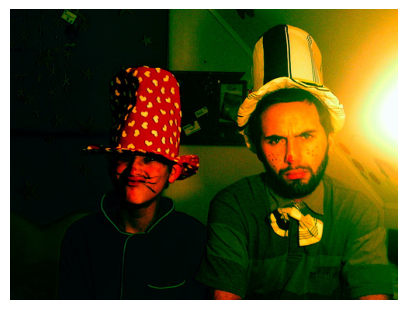

Caption từ bộ dữ liệu      : the hatted males pose for a picture
Thuật toán Beam (=3)    : a man in a black jacket and a woman in a black jacket
Thuật toán Greedy    : a man in a black jacket and a woman in a black jacket and a black hat and a woman in a black jacket



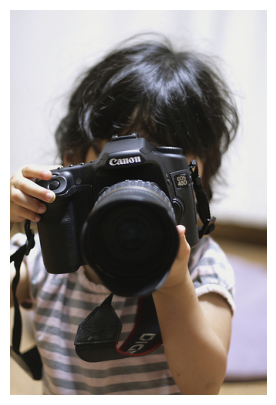

Caption từ bộ dữ liệu      : a child is holding up a camera in front of its face
Thuật toán Beam (=3)    : a man in a blue shirt is holding a stick in his mouth
Thuật toán Greedy    : a man in a blue shirt and a white shirt is holding a camera



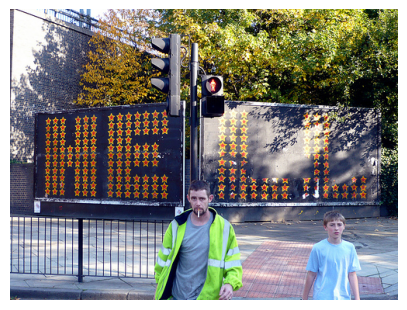

Caption từ bộ dữ liệu      : a man and a boy standing in front of a sign that says hell
Thuật toán Beam (=3)    : a man in a blue shirt is standing in front of a building
Thuật toán Greedy    : a man in a blue shirt and a black hat is standing on a sidewalk



In [ ]:
for name in random.sample(test_imgs, 3):
    plt.figure(figsize=(5, 5))
    plt.imshow(Image.open(f"{IMG_DIR}/{name}")); plt.axis("off"); plt.show()
    print("Caption từ bộ dữ liệu      :", captions_by_img[name][0].replace(START, "").replace(END, "").strip())
    print("Thuật toán Beam (=3)    :", generate_caption(F[feat_index[name]], beam=3))
    print("Thuật toán Greedy    :", generate_caption(F[feat_index[name]], beam=1))
    print()

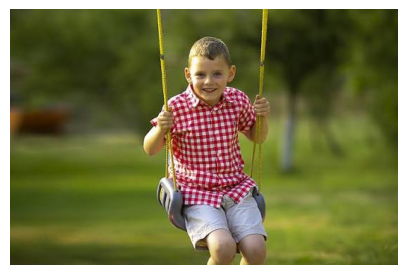

Du doan anh tu nguoi dung(Beam=3):  a little girl in a pink shirt is swinging on a swing


In [ ]:
plt.figure(figsize=(5, 5))
plt.imshow(Image.open("/content/anh_test_IC3.jpg")); plt.axis("off"); plt.show()
print("Du doan anh tu nguoi dung(Beam=3): ", caption_from_file("/content/anh_test_IC3.jpg"))

In [ ]:
model.save(f"{BASE}/caption_model_v2.keras")
print("Đã lưu:", f"{BASE}/caption_model_v2.keras")

Đã lưu: /content/drive/MyDrive/ImageCaption_Update/caption_model_v2.keras


Để gọi lại model thì chạy build lại kiến trúc model

In [ ]:
from tensorflow.keras.models import load_model
model = load_model(f"{BASE}/caption_model_v2.keras")